In [2]:
import matplotlib.pyplot as plt

# Set up publication-quality plot settings
plt.rcParams.update({
    "figure.figsize": (3, 2),  # Default figure size (in inches)
    "font.size": 14,           # Base font size
    "axes.labelsize": 14,      # Label font size
    "axes.titlesize": 14,      # Title font size
    "legend.fontsize": 14,     # Legend font size
    "xtick.labelsize": 14,     # X-axis tick labels size
    "ytick.labelsize": 14,     # Y-axis tick labels size
    "axes.linewidth": 1.2,     # Line width of axes
    "lines.linewidth": 4,      # Line thickness
    "lines.markersize": 6,     # Marker size
    "xtick.direction": "in",   # Ticks inside the plot
    "ytick.direction": "in",
    "xtick.major.size": 6,     # Major tick size
    "ytick.major.size": 6,
    "xtick.minor.size": 3,     # Minor tick size
    "ytick.minor.size": 3,
    "xtick.major.width": 1,    # Major tick width
    "ytick.major.width": 1,
    "xtick.minor.width": 0.8,  # Minor tick width
    "ytick.minor.width": 0.8,
    "legend.frameon": False,   # No box around the legend
    "axes.grid": True,         # Enable grid
    "grid.linestyle": "--",    # Dashed grid lines
    "grid.alpha": 0.5,         # Grid transparency
    "savefig.dpi": 300,        # High-resolution figures
    "savefig.format": "png",   # Default save format
    "font.family": "serif",    # Use serif font (e.g., Times)
    "font.serif": ["Times New Roman", "DejaVu Serif"],  # Preferred serif fonts
    "mathtext.fontset": "cm",  # Computer Modern for math
    "axes.prop_cycle": plt.cycler("color", ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"])
})


In [3]:
import os
import numpy as np
import pandas as pd

def process_file(filename, x_col="arc_length", y_col="nplus:0"):
    """
    Load a CSV file, filter NaNs, and compute the integral of y_col over x_col.
    
    Parameters:
        filename (str): Path to the CSV file.
        x_col (str): Name of the column representing x-values (default: 'arc_length').
        y_col (str): Name of the column representing y-values (default: 'nplus:0').
    
    Returns:
        float: Computed integral, or None if an error occurs.
    """
    try:
        df = pd.read_csv(filename)

        # Drop rows with NaN values in the specified columns
        df_clean = df.dropna(subset=[x_col, y_col])

        # Extract x and y values
        x = df_clean[x_col].values  
        y = df_clean[y_col].values  

        # Compute the integral using NumPy's trapezoidal rule
        integral = np.trapezoid(y, x)
        return integral
    
    except Exception as e:
        print(f"Error processing {filename}: {e}")
        return None

def analyze_integrals(folder, radii=[10, 20, 30, 40, 50], filename_pattern="mid_pore_r_{}nm.csv", x_col="arc_length", y_col="nplus:0"):
    """
    Process multiple files in a specified folder and compute integrals for different radii.
    
    Parameters:
        folder (str): Path to the folder containing the CSV files.
        radii (list): List of radii to analyze.
        filename_pattern (str): Filename pattern where '{}' represents the radius.
        x_col (str): Name of the x-values column (default: 'arc_length').
        y_col (str): Name of the y-values column (default: 'nplus:0').
    
    Returns:
        tuple: (radii, integrals) as NumPy arrays.
    """
    # Initialize an empty list to store integrals
    integrals = []

    # Loop over each radius, process the corresponding file, and store the result
    for r in radii:
        filename = os.path.join(folder, filename_pattern.format(r))  # Construct full filepath
        integral = process_file(filename, x_col=x_col, y_col=y_col)
        
        if integral is not None:
            integrals.append(integral)
        else:
            integrals.append(np.nan)  # Keep NaN if processing failed

    # Convert results to NumPy arrays for plotting
    radii = np.array(radii)
    integrals = np.array(integrals)

   

    return radii, integrals

def extract_different_fluxes(folder,radii=[2,10],filename_pattern = "postprocessing_r{}.csv",r_col="arc_length",fluxes=["diff_flux_cplus:0","diff_size_cplus:0","migration_flux_cplus:0","total_flux_cplus:0"]):
    """
    Process multiple .csv file after the paraview postprocessing 
    and extract the position from r = 0 to R, as well as different 
    fluxes along as a function of r. 
    This procedure is done for R = radii.
    
    
    """
    # Initialize an empty list to store different fluxes as well as radii vectors
    # for each radius R in radii
    r_list = [0]* len(radii)
    flux_list = [[0]*len(fluxes) for _ in range(len(radii))]

    # Loop over each radius, process the corresponding file, and store the result
    for (r_idx,r) in enumerate(radii):
        filename = os.path.join(folder, filename_pattern.format(r))  # Construct full filepath
        df = pd.read_csv(filename)
        # Drop rows with NaN values in the specified columns
        df = df.dropna()
        r_list[r_idx] = df[r_col]/max(df[r_col]) # divide by R to get values from 0 to 1
        for (f_idx,flux) in enumerate(fluxes):
            flux_list[r_idx][f_idx] = df[flux].values

    return r_list, flux_list
    

    

In [ ]:
[radii,fluxes] = extract_different_fluxes("/Users/nik/Documents/projects/2025_IonTrappingInCoatedSeparator_OSU_Collaboration/Data/20250417_r_dependency_h80",radii=[2])

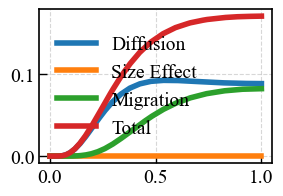

In [31]:
for (r_idx,r) in enumerate(radii):
    plt.plot(r,fluxes[r_idx][0])
    plt.plot(r,fluxes[r_idx][1])
    plt.plot(r,fluxes[r_idx][2])
    plt.plot(r,fluxes[r_idx][3])
    plt.legend(["Diffusion","Size Effect","Migration","Total"])

In [6]:
radii,fluxes = analyze_integrals("/Users/nik/Documents/projects/2025_IonTrappingInCoatedSeparator_OSU_Collaboration/Data/20250417_r_dependency_h80",[1.5,2,3,4,5,6,8,10],filename_pattern="postprocessing_r{}.csv",x_col="arc_length",y_col="total_flux_cplus:0")


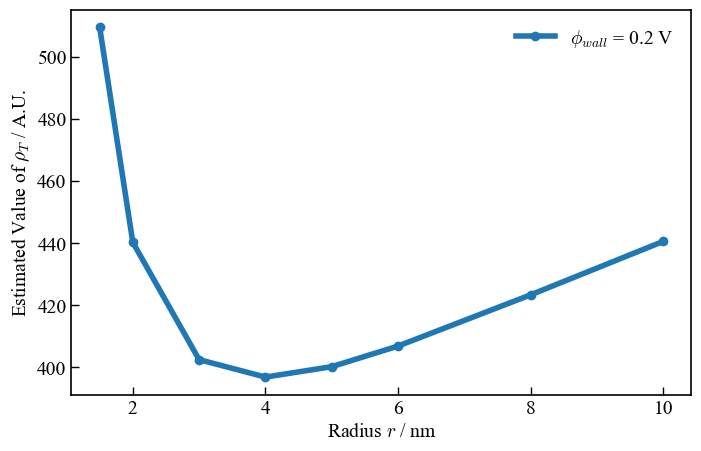

In [7]:
 # Plot radii vs computed integrals
plt.figure(figsize=(8, 5))
plt.plot(radii, abs(radii/fluxes), marker='o', linestyle='-')

plt.xlabel("Radius $r$ / nm")
plt.ylabel(r"Estimated Value of $\rho_T$ / A.U.")
#plt.title(f"Radius vs Integral of {y_col} over {x_col}")
plt.legend(["$\phi_{wall}$ = 0.2 V","$\phi_{wall}$ = 0.3 V"])
plt.grid()
plt.show()

In [22]:
h,fluxes_h = analyze_integrals("../data/H_dependency",[20,40,80,120],filename_pattern="midpore_h{}_r10_L50.csv")

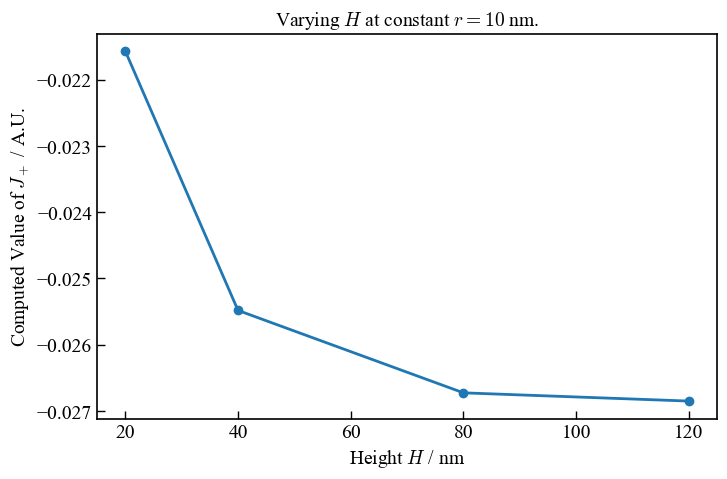

In [ ]:
 # Plot radii vs computed integrals
plt.figure(figsize=(8, 5))
plt.plot(h, fluxes_h, marker='o', linestyle='-')
plt.xlabel("Height $H$ / nm")
plt.ylabel(r"Computed Value of $J_+$ / A.U.")
plt.title(f"Varying $H$ at constant $r  = 10$ nm.")
plt.grid()
plt.show()

In [4]:
h20,flux_20 = analyze_integrals("/Users/nik/Documents/projects/2025_IonTrappingInCoatedSeparator_OSU_Collaboration/Data/postprocessing_outputs/20250506_r_10nm_h_20nm_l_50nm_phiT_50/",[20],filename_pattern="extract_pore_center_radius_line.csv",y_col="total_flux_cplus:0")
h40,flux_40 = analyze_integrals("/Users/nik/Documents/projects/2025_IonTrappingInCoatedSeparator_OSU_Collaboration/Data/postprocessing_outputs/20250506_r_10nm_h_40nm_l_50nm_phiT_15/",[40],filename_pattern="extract_pore_center_radius_line.csv",y_col="total_flux_cplus:0")
h80,flux_80 = analyze_integrals("/Users/nik/Documents/projects/2025_IonTrappingInCoatedSeparator_OSU_Collaboration/Data/postprocessing_outputs/20250506_r_10nm_h_80nm_l_50nm_phiT_15/",[80],filename_pattern="extract_pore_center_radius_line.csv",y_col="total_flux_cplus:0")
h120,flux_120 = analyze_integrals("/Users/nik/Documents/projects/2025_IonTrappingInCoatedSeparator_OSU_Collaboration/Data/postprocessing_outputs/20250506_r_10nm_h_120nm_l_50nm_phiT_15/",[120],filename_pattern="extract_pore_center_radius_line.csv",y_col="total_flux_cplus:0")

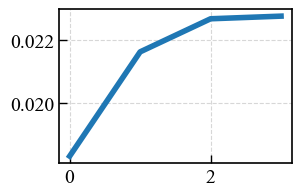

In [5]:
plt.plot([flux_20,flux_40,flux_80,flux_120])

array([-0.00370174])